# 네트워크 침입 탐지 — MLflow Pipeline v8

## 가설 H8: 같은 날짜·시간대의 Benign을 매칭하면 Flow 기반 Infilteration 분리가 개선된다

v7에서 Timestamp를 직접 모델 피처로 사용하자 검증 후반을 거의 전부 Infilteration으로 판단했습니다.
v8에서는 Timestamp를 **모델 입력에서 완전히 제외**하고 학습 표본 매칭에만 사용합니다.

1. v6 구조로 DDOS/DoS/Brute Force를 먼저 라우팅
2. Residual 학습셋에서 각 Infilteration과 같은 `date + hour`의 Benign을 매칭
3. Benign 매칭 비율 1/3/5/10배 비교
4. Residual 모델에는 Flow 및 TCP 파생변수만 입력
5. 검증셋은 매칭하지 않은 실제 불균형 분포 그대로 평가

선택된 모델은 2월 28일까지 학습하고 3월 1일을 검증하는 날짜 Holdout도 통과해야 합니다.


In [1]:
from pathlib import Path
import json
import os
import time
import warnings

import duckdb
import matplotlib.pyplot as plt
import mlflow
import mlflow.sklearn
import numpy as np
import pandas as pd
import seaborn as sns
from lightgbm import LGBMClassifier
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)

HYPOTHESIS_ID = "v8"
HYPOTHESIS = "time_matched_benign_vs_infilteration_flow_specialist"
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

WORK_ROOT = Path("/home/jovyan/work")
cwd = Path.cwd()
PROJECT_NAME = cwd.parent.name if cwd.name == "notebooks" else "network-classification"
PROJECT_DIR = WORK_ROOT / PROJECT_NAME
DATA_BASE = WORK_ROOT / "datasets"

def has_temporal_train(path: Path) -> bool:
    return (path / "processed" / "train_temporal_v5.parquet").exists()

preferred = DATA_BASE / PROJECT_NAME
if has_temporal_train(preferred):
    DATA_ROOT = preferred
else:
    matches = [p for p in DATA_BASE.iterdir() if p.is_dir() and has_temporal_train(p)]
    if len(matches) != 1:
        raise RuntimeError(f"Temporal 데이터 프로젝트를 결정할 수 없습니다: {matches}")
    DATA_ROOT = matches[0]

PROCESSED_DIR = DATA_ROOT / "processed"
TRAIN_TEMPORAL = PROCESSED_DIR / "train_temporal_v5.parquet"
TEST_TEMPORAL = PROCESSED_DIR / "test_temporal_v5.parquet"
OUTPUT_DIR = PROJECT_DIR / "outputs" / HYPOTHESIS_ID
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

ID_COL = "unique_id"
TARGET = "Label"
CAT_FEATURES = ["Dst Port", "Protocol"]
KNOWN_ATTACKS = ["Brute Force", "DDOS", "DoS"]
TRAIN_SAMPLE = 250_000
VALID_FRACTION = 0.20
MATCH_RATIOS = [1, 3, 5, 10]
INF_THRESHOLDS = np.round(np.arange(0.05, 0.96, 0.05), 2)
KNOWN_ATTACK_THRESHOLD = 0.45

CONTEXT_FEATURES = [
    "prev_distinct_ts_gap_s",
    "prior_events_10s_per_million",
    "prior_events_60s_per_million",
    "prior_events_300s_per_million",
    "prior_flow_pkts_s_mean_60s",
    "prior_flow_byts_s_mean_60s",
    "prior_total_pkts_mean_60s",
]
CALENDAR_FEATURES = ["hour_sin", "hour_cos", "dow_sin", "dow_cos", "elapsed_hours"]
TEMPORAL_FEATURES = [*CONTEXT_FEATURES, *CALENDAR_FEATURES]

V6_BASELINE = {
    "weighted_f1_attacks": 0.9202514012197288,
    "macro_f1_attacks": 0.7541476007767233,
    "accuracy": 0.9089381451548372,
    "infilteration_precision": 0.09265507396833636,
    "infilteration_recall": 0.4594594594594595,
    "infilteration_f1": 0.15421166306695464,
    "benign_to_infilteration_fp": 3496,
    "bruteforce_f1": 0.9204609331084879,
    "ddos_f1": 0.9941826152938201,
    "dos_f1": 0.9477351916376306,
}

MLFLOW_TRACKING_URI = os.getenv("MLFLOW_TRACKING_URI", "http://mlflow:5000")
EXPERIMENT_NAME = f"{PROJECT_NAME}-ids-{HYPOTHESIS_ID}"
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(EXPERIMENT_NAME)

print("Project    :", PROJECT_NAME)
print("Data root  :", DATA_ROOT)
print("Output     :", OUTPUT_DIR)
print("Experiment :", EXPERIMENT_NAME)


2026/08/15 17:18:57 INFO mlflow.tracking.fluent: Experiment with name 'network-classification-ids-v8' does not exist. Creating a new experiment.


Project    : network-classification
Data root  : /home/jovyan/work/datasets/ 📁 network-classification
Output     : /home/jovyan/work/network-classification/outputs/v8
Experiment : network-classification-ids-v8


## 1. 샘플 로딩 및 Flow 피처 구성

In [2]:
def sql_path(path: Path) -> str:
    return str(path).replace("'", "''")

def parquet_expr(path: Path) -> str:
    return f"read_parquet('{sql_path(path)}')"

def load_sample(path: Path, n_rows: int):
    with duckdb.connect() as con:
        return con.execute(f'''
            SELECT * FROM {parquet_expr(path)}
            USING SAMPLE reservoir({int(n_rows)} ROWS)
            REPEATABLE ({RANDOM_STATE})
        ''').df()

def add_ids_features(df: pd.DataFrame):
    df = df.copy()
    flag_cols = [
        "SYN Flag Cnt", "ACK Flag Cnt", "RST Flag Cnt",
        "FIN Flag Cnt", "URG Flag Cnt", "PSH Flag Cnt",
    ]
    if all(c in df.columns for c in flag_cols):
        values = {
            c: pd.to_numeric(df[c], errors="coerce").fillna(0).astype(float)
            for c in flag_cols
        }
        syn, ack = values["SYN Flag Cnt"], values["ACK Flag Cnt"]
        rst, fin = values["RST Flag Cnt"], values["FIN Flag Cnt"]
        urg, psh = values["URG Flag Cnt"], values["PSH Flag Cnt"]
        total_flags = syn + ack + rst + fin + urg + psh + 1.0
        df["SYN_ACK_ratio"] = (syn + 1) / (ack + 1)
        df["RST_ACK_ratio"] = (rst + 1) / (ack + 1)
        df["SYN_RST_over_ACK_FIN"] = (syn + rst + 1) / (ack + fin + 1)
        df["ACK_SYN_ratio"] = (ack + 1) / (syn + 1)
        df["URG_ACK_ratio"] = (urg + 1) / (ack + 1)
        df["SYN_share"] = (syn + 1) / total_flags
        df["RST_share"] = (rst + 1) / total_flags
    numeric = df.select_dtypes(include=[np.number]).columns
    df[numeric] = df[numeric].replace([np.inf, -np.inf], np.nan)
    return df

train_df = add_ids_features(load_sample(TRAIN_TEMPORAL, TRAIN_SAMPLE))
train_df["Timestamp"] = pd.to_datetime(train_df["Timestamp"])
train_df["match_hour"] = train_df["Timestamp"].dt.floor("h")
y_all = train_df[TARGET].astype(str)
classes = sorted(y_all.unique().tolist())
attack_classes = [c for c in classes if c != "Benign"]
INFILTRATION_LABEL = next(
    c for c in classes if c.lower() in {"infiltration", "infilteration"}
)

X_router = train_df.drop(
    columns=[TARGET, ID_COL, "Timestamp", "match_hour", *CALENDAR_FEATURES],
    errors="ignore",
)
X_flow = train_df.drop(
    columns=[TARGET, ID_COL, "Timestamp", "match_hour", *TEMPORAL_FEATURES],
    errors="ignore",
)
for frame in [X_router, X_flow]:
    for column in CAT_FEATURES:
        if column in frame.columns:
            frame[column] = frame[column].astype("string")

print("Loaded:", train_df.shape)
print("Router features:", X_router.shape[1])
print("Residual Flow features:", X_flow.shape[1])


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Loaded: (250000, 63)
Router features: 54
Residual Flow features: 47


## 2. 클래스별 시간 블록 검증

In [3]:
class_cutoffs = train_df.groupby(TARGET)["Timestamp"].quantile(1 - VALID_FRACTION)
cutoff_per_row = train_df[TARGET].map(class_cutoffs)
valid_mask = train_df["Timestamp"] > cutoff_per_row
train_mask = ~valid_mask
y_train, y_valid = y_all.loc[train_mask], y_all.loc[valid_mask]

split_distribution = pd.crosstab(
    pd.Series(np.where(valid_mask, "valid_late", "train_early"), index=train_df.index),
    y_all,
)
display(class_cutoffs.to_frame("cutoff"))
display(split_distribution)
assert (split_distribution > 0).all().all()


,cutoff
Label,
Benign,2018-02-28 11:15:54.000
Brute Force,2018-02-14 11:32:57.200
DDOS,2018-02-21 02:27:14.000
DoS,2018-02-16 10:13:27.000
Infilteration,2018-03-01 03:34:09.000


Label,Benign,Brute Force,DDOS,DoS,Infilteration
row_0,,,,,
train_early,137495,13146,23894,22345,3132
valid_late,34373,3287,5965,5586,777


In [4]:
def make_preprocessor(frame):
    cat_features = [c for c in CAT_FEATURES if c in frame.columns]
    num_features = [c for c in frame.columns if c not in cat_features]
    return ColumnTransformer([
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="constant", fill_value=0)),
            ("scaler", StandardScaler()),
        ]), num_features),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True)),
        ]), cat_features),
    ])

def make_lgbm(objective, class_weight, n_estimators=500):
    return LGBMClassifier(
        n_estimators=n_estimators, learning_rate=0.05, num_leaves=63,
        max_depth=-1, subsample=0.9, colsample_bytree=0.9,
        objective=objective, class_weight=class_weight,
        random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1,
    )

def evaluate(y_true, y_pred):
    metrics = {
        "weighted_f1_attacks": float(f1_score(
            y_true, y_pred, labels=attack_classes,
            average="weighted", zero_division=0,
        )),
        "macro_f1_attacks": float(f1_score(
            y_true, y_pred, labels=attack_classes,
            average="macro", zero_division=0,
        )),
        "accuracy": float(accuracy_score(y_true, y_pred)),
    }
    for label, prefix in [
        (INFILTRATION_LABEL, "infilteration"),
        ("Brute Force", "bruteforce"), ("DDOS", "ddos"), ("DoS", "dos"),
    ]:
        p, r, f, _ = precision_recall_fscore_support(
            y_true, y_pred, labels=[label], average=None, zero_division=0
        )
        metrics[f"{prefix}_precision"] = float(p[0])
        metrics[f"{prefix}_recall"] = float(r[0])
        metrics[f"{prefix}_f1"] = float(f[0])
    yt, yp = np.asarray(y_true), np.asarray(y_pred)
    metrics["benign_to_infilteration_fp"] = int(np.sum(
        (yt == "Benign") & (yp == INFILTRATION_LABEL)
    ))
    return metrics

def save_evaluation(name, y_true, y_pred):
    report_path = OUTPUT_DIR / f"{name}_classification_report.csv"
    pd.DataFrame(classification_report(
        y_true, y_pred, labels=classes, output_dict=True, zero_division=0
    )).T.to_csv(report_path, encoding="utf-8-sig")
    cm = confusion_matrix(y_true, y_pred, labels=classes)
    fig, ax = plt.subplots(figsize=(8, 7))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=classes, yticklabels=classes, ax=ax)
    ax.set(title=f"Confusion Matrix — {name}", xlabel="Predicted", ylabel="Actual")
    plt.tight_layout()
    cm_path = OUTPUT_DIR / f"{name}_confusion_matrix.png"
    fig.savefig(cm_path, dpi=140, bbox_inches="tight")
    plt.close(fig)
    return report_path, cm_path


## 3. v6 기반 알려진 공격 라우터

In [5]:
y_attack_binary_train = (y_train != "Benign").astype(int)
attack_train_mask = train_mask & (y_all != "Benign")
y_attack_subtype_train = y_all.loc[attack_train_mask]

attack_gate = Pipeline([
    ("preprocess", make_preprocessor(X_router)),
    ("model", make_lgbm("binary", "balanced", n_estimators=400)),
])
subtype_weight_values = compute_class_weight(
    class_weight="balanced", classes=np.asarray(attack_classes),
    y=y_attack_subtype_train.to_numpy(),
)
subtype_weights = dict(zip(attack_classes, subtype_weight_values.astype(float)))
attack_subtype = Pipeline([
    ("preprocess", make_preprocessor(X_router)),
    ("model", make_lgbm("multiclass", subtype_weights)),
])

attack_gate.fit(X_router.loc[train_mask], y_attack_binary_train)
attack_subtype.fit(X_router.loc[attack_train_mask], y_attack_subtype_train)
valid_attack_probability = attack_gate.predict_proba(X_router.loc[valid_mask])[:, 1]
valid_attack_subtype = attack_subtype.predict(X_router.loc[valid_mask])
valid_accept_known = (
    np.isin(valid_attack_subtype, KNOWN_ATTACKS)
    & (valid_attack_probability >= KNOWN_ATTACK_THRESHOLD)
)
print("Known accepted:", int(valid_accept_known.sum()))


Known accepted: 14758


## 4. 동일 날짜·시간대 Benign 매칭

각 시간 bin에서 Infilteration은 모두 유지하고, 동일 bin의 Benign만 설정 비율까지 비복원 추출합니다.
Benign이 없는 시간 bin의 Infilteration은 학습에서 제외하고 매칭 커버리지를 기록합니다.


In [6]:
def build_matched_indices(eligible_mask, benign_ratio, seed=RANDOM_STATE):
    eligible = train_df.loc[eligible_mask, [TARGET, "match_hour"]]
    selected_inf = []
    selected_benign = []
    matched_bins = 0
    unmatched_inf = 0

    for bin_number, (hour, group) in enumerate(eligible.groupby("match_hour", sort=True)):
        inf_index = group.index[group[TARGET] == INFILTRATION_LABEL]
        benign_index = group.index[group[TARGET] == "Benign"]
        if len(inf_index) == 0:
            continue
        if len(benign_index) == 0:
            unmatched_inf += len(inf_index)
            continue
        matched_bins += 1
        take = min(len(benign_index), benign_ratio * len(inf_index))
        rng = np.random.default_rng(seed + benign_ratio * 1000 + bin_number)
        chosen_benign = rng.choice(benign_index.to_numpy(), size=take, replace=False)
        selected_inf.extend(inf_index.tolist())
        selected_benign.extend(chosen_benign.tolist())

    indices = pd.Index([*selected_inf, *selected_benign])
    stats = {
        "benign_ratio": benign_ratio,
        "matched_bins": matched_bins,
        "matched_infilteration": len(selected_inf),
        "matched_benign": len(selected_benign),
        "unmatched_infilteration": unmatched_inf,
        "coverage": len(selected_inf) / max(1, len(selected_inf) + unmatched_inf),
    }
    return indices, stats

residual_train_mask = train_mask & y_all.isin(["Benign", INFILTRATION_LABEL])
matched_sets = {}
matching_stats = []
for ratio in MATCH_RATIOS:
    indices, stats = build_matched_indices(residual_train_mask, ratio)
    matched_sets[ratio] = indices
    matching_stats.append(stats)

matching_summary = pd.DataFrame(matching_stats)
matching_path = OUTPUT_DIR / "v8_matching_summary.csv"
matching_summary.to_csv(matching_path, index=False, encoding="utf-8-sig")
display(matching_summary)


,benign_ratio,matched_bins,matched_infilteration,matched_benign,unmatched_infilteration,coverage
0,1,4,1539,1097,1593,0.491379
1,3,4,1539,2459,1593,0.491379
2,5,4,1539,3155,1593,0.491379
3,10,4,1539,4178,1593,0.491379


## 5. 매칭 비율별 Flow 전용 Residual 모델과 임계값 탐색

In [7]:
matched_models = {}
valid_inf_probabilities = {}
candidate_rows = []

for ratio, indices in matched_sets.items():
    y_matched = (y_all.loc[indices] == INFILTRATION_LABEL).astype(int)
    pipeline = Pipeline([
        ("preprocess", make_preprocessor(X_flow)),
        ("model", make_lgbm("binary", None, n_estimators=400)),
    ])
    started = time.time()
    pipeline.fit(X_flow.loc[indices], y_matched)
    probability = pipeline.predict_proba(X_flow.loc[valid_mask])[:, 1]
    matched_models[ratio] = pipeline
    valid_inf_probabilities[ratio] = probability
    train_seconds = time.time() - started

    for inf_threshold in INF_THRESHOLDS:
        residual_pred = np.where(
            probability >= inf_threshold, INFILTRATION_LABEL, "Benign"
        )
        combined_pred = np.where(
            valid_accept_known, valid_attack_subtype, residual_pred
        )
        candidate_rows.append({
            "benign_ratio": ratio,
            "inf_threshold": inf_threshold,
            **evaluate(y_valid, combined_pred),
            "train_seconds": train_seconds,
        })

candidates = pd.DataFrame(candidate_rows)
candidates_path = OUTPUT_DIR / "v8_matched_threshold_search.csv"
candidates.to_csv(candidates_path, index=False, encoding="utf-8-sig")
display(candidates.sort_values(
    ["infilteration_f1", "macro_f1_attacks"], ascending=False
).head(30))


,benign_ratio,inf_threshold,weighted_f1_attacks,macro_f1_attacks,accuracy,infilteration_precision,infilteration_recall,infilteration_f1,bruteforce_precision,bruteforce_recall,bruteforce_f1,ddos_precision,ddos_recall,ddos_f1,dos_precision,dos_recall,dos_f1,benign_to_infilteration_fp,train_seconds
32,3,0.70,0.915265,0.729095,0.810775,0.029453,0.324324,0.054002,0.855315,0.996349,0.920461,1.0,0.988433,0.994183,0.999801,0.900823,0.947735,8298,1.003366
46,5,0.45,0.915238,0.728962,0.707670,0.028218,0.508366,0.053469,0.855315,0.996349,0.920461,1.0,0.988433,0.994183,0.999801,0.900823,0.947735,13595,0.973706
48,5,0.55,0.915232,0.728931,0.769345,0.028603,0.395109,0.053345,0.855315,0.996349,0.920461,1.0,0.988433,0.994183,0.999801,0.900823,0.947735,10424,0.973706
31,3,0.65,0.915219,0.728866,0.776866,0.028538,0.379665,0.053086,0.855315,0.996349,0.920461,1.0,0.988433,0.994183,0.999801,0.900823,0.947735,10036,1.003366
30,3,0.60,0.915212,0.728828,0.746179,0.028187,0.433719,0.052933,0.855315,0.996349,0.920461,1.0,0.988433,0.994183,0.999801,0.900823,0.947735,11612,1.003366
47,5,0.50,0.915187,0.728704,0.737917,0.027863,0.444015,0.052436,0.855315,0.996349,0.920461,1.0,0.988433,0.994183,0.999801,0.900823,0.947735,12033,0.973706
49,5,0.60,0.915181,0.728673,0.798132,0.028366,0.335907,0.052315,0.855315,0.996349,0.920461,1.0,0.988433,0.994183,0.999801,0.900823,0.947735,8939,0.973706
66,10,0.50,0.915169,0.728611,0.776066,0.027984,0.373230,0.052065,0.855315,0.996349,0.920461,1.0,0.988433,0.994183,0.999801,0.900823,0.947735,10071,0.928722
52,5,0.75,0.915165,0.728594,0.878611,0.030077,0.191763,0.051998,0.855315,0.996349,0.920461,1.0,0.988433,0.994183,0.999801,0.900823,0.947735,4804,0.973706
29,3,0.55,0.915162,0.728578,0.713531,0.027442,0.482625,0.051932,0.855315,0.996349,0.920461,1.0,0.988433,0.994183,0.999801,0.900823,0.947735,13282,1.003366


## 6. Champion 후보 선택과 v6 비교

In [8]:
known_guard = (
    (candidates["bruteforce_f1"] >= 0.90)
    & (candidates["ddos_f1"] >= 0.98)
    & (candidates["dos_f1"] >= 0.90)
)
operational = candidates[
    known_guard
    & (candidates["accuracy"] >= 0.88)
    & (candidates["infilteration_recall"] >= 0.40)
    & (candidates["benign_to_infilteration_fp"] <= 4500)
]

if operational.empty:
    selection_tier = "fallback"
    selection_pool = candidates[known_guard]
else:
    selection_tier = "operational"
    selection_pool = operational
if selection_pool.empty:
    selection_tier = "unconstrained_fallback"
    selection_pool = candidates

selected = selection_pool.sort_values(
    ["infilteration_f1", "infilteration_recall", "accuracy"],
    ascending=False,
).iloc[0]
selected_ratio = int(selected["benign_ratio"])
selected_inf_threshold = float(selected["inf_threshold"])

selected_residual_pred = np.where(
    valid_inf_probabilities[selected_ratio] >= selected_inf_threshold,
    INFILTRATION_LABEL,
    "Benign",
)
champion_pred = np.where(
    valid_accept_known, valid_attack_subtype, selected_residual_pred
)
champion_metrics = evaluate(y_valid, champion_pred)
delta_vs_v6 = {
    key: champion_metrics[key] - V6_BASELINE[key]
    for key in [
        "weighted_f1_attacks", "macro_f1_attacks", "accuracy",
        "infilteration_precision", "infilteration_recall", "infilteration_f1",
        "benign_to_infilteration_fp", "bruteforce_f1", "ddos_f1", "dos_f1",
    ]
}

print("Selection tier       :", selection_tier)
print("Selected benign ratio:", selected_ratio)
print("Selected threshold   :", selected_inf_threshold)
print("Champion metrics     :", champion_metrics)
print("Delta vs v6          :", delta_vs_v6)


Selection tier       : fallback
Selected benign ratio: 3
Selected threshold   : 0.7
Champion metrics     : {'weighted_f1_attacks': 0.9152649802367315, 'macro_f1_attacks': 0.7290951671700617, 'accuracy': 0.8107745859006161, 'infilteration_precision': 0.029453015427769985, 'infilteration_recall': 0.32432432432432434, 'infilteration_f1': 0.05400192864030858, 'bruteforce_precision': 0.8553147035779577, 'bruteforce_recall': 0.9963492546394889, 'bruteforce_f1': 0.9204609331084879, 'ddos_precision': 1.0, 'ddos_recall': 0.9884325230511316, 'ddos_f1': 0.9941826152938201, 'dos_precision': 0.9998013113451222, 'dos_recall': 0.9008234872896527, 'dos_f1': 0.9477351916376306, 'benign_to_infilteration_fp': 8298}
Delta vs v6          : {'weighted_f1_attacks': -0.004986420982997286, 'macro_f1_attacks': -0.02505243360666154, 'accuracy': -0.09816355925422104, 'infilteration_precision': -0.06320205854056637, 'infilteration_recall': -0.13513513513513514, 'infilteration_f1': -0.10020973442664605, 'benign_to_

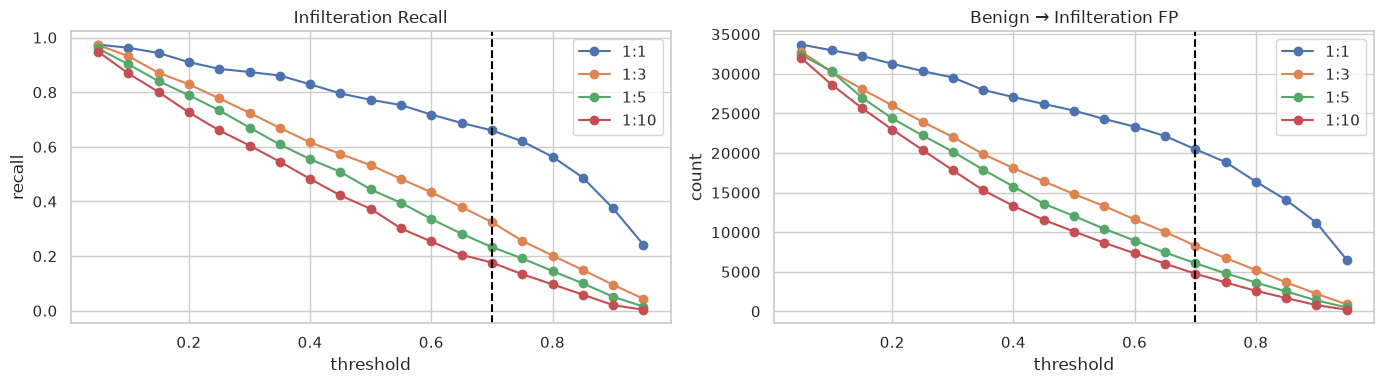

In [9]:
champion_report, champion_cm = save_evaluation(
    "v8_matched_champion", y_valid, champion_pred
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ratio, group in candidates.groupby("benign_ratio"):
    group = group.sort_values("inf_threshold")
    axes[0].plot(group["inf_threshold"], group["infilteration_recall"], marker="o", label=f"1:{ratio}")
    axes[1].plot(group["inf_threshold"], group["benign_to_infilteration_fp"], marker="o", label=f"1:{ratio}")
axes[0].set(title="Infilteration Recall", xlabel="threshold", ylabel="recall")
axes[1].set(title="Benign → Infilteration FP", xlabel="threshold", ylabel="count")
for ax in axes:
    ax.axvline(selected_inf_threshold, color="black", linestyle="--")
    ax.legend()
plt.tight_layout()
tradeoff_path = OUTPUT_DIR / "v8_matching_tradeoff.png"
fig.savefig(tradeoff_path, dpi=140, bbox_inches="tight")
plt.show()


## 7. 날짜 Holdout — 2월 28일까지 매칭 학습, 3월 1일 검증

In [10]:
holdout_train_mask = (
    y_all.isin(["Benign", INFILTRATION_LABEL])
    & (train_df["Timestamp"] < pd.Timestamp("2018-03-01"))
)
holdout_valid_mask = (
    y_all.isin(["Benign", INFILTRATION_LABEL])
    & (train_df["Timestamp"] >= pd.Timestamp("2018-03-01"))
    & (train_df["Timestamp"] < pd.Timestamp("2018-03-02"))
)
holdout_indices, holdout_match_stats = build_matched_indices(
    holdout_train_mask, selected_ratio, seed=RANDOM_STATE + 10000
)
holdout_y_train = (y_all.loc[holdout_indices] == INFILTRATION_LABEL).astype(int)
holdout_model = Pipeline([
    ("preprocess", make_preprocessor(X_flow)),
    ("model", make_lgbm("binary", None, n_estimators=400)),
])
holdout_model.fit(X_flow.loc[holdout_indices], holdout_y_train)
holdout_probability = holdout_model.predict_proba(X_flow.loc[holdout_valid_mask])[:, 1]
holdout_pred = (holdout_probability >= selected_inf_threshold).astype(int)
holdout_y_valid = (y_all.loc[holdout_valid_mask] == INFILTRATION_LABEL).astype(int).to_numpy()
hp, hr, hf, _ = precision_recall_fscore_support(
    holdout_y_valid, holdout_pred, labels=[1], average=None, zero_division=0
)
holdout_metrics = {
    "holdout_precision": float(hp[0]),
    "holdout_recall": float(hr[0]),
    "holdout_f1": float(hf[0]),
    "holdout_accuracy": float(accuracy_score(holdout_y_valid, holdout_pred)),
    "holdout_train_rows": len(holdout_indices),
    "holdout_valid_rows": len(holdout_y_valid),
    "holdout_valid_infilteration": int(holdout_y_valid.sum()),
}
print("Holdout matching:", holdout_match_stats)
print("Date holdout metrics:", holdout_metrics)
display(pd.crosstab(
    pd.Series(holdout_y_valid, name="actual"),
    pd.Series(holdout_pred, name="predicted"),
))


Holdout matching: {'benign_ratio': 3, 'matched_bins': 5, 'matched_infilteration': 1603, 'matched_benign': 3483, 'unmatched_infilteration': 0, 'coverage': 1.0}
Date holdout metrics: {'holdout_precision': 0.2919280635717273, 'holdout_recall': 0.3026886383347788, 'holdout_f1': 0.2972109857355759, 'holdout_accuracy': 0.600894692298392, 'holdout_train_rows': 5086, 'holdout_valid_rows': 8271, 'holdout_valid_infilteration': 2306}


predicted,0,1
actual,,
0,4272,1693
1,1608,698


## 8. 가설 판정 및 MLflow 기록

승인 조건: v6보다 Infilteration F1 향상, Recall ≥ 0.55, Accuracy ≥ 0.89,
정상 오탐 ≤ 4,000, 날짜 Holdout F1 ≥ 0.15.


In [11]:
hypothesis_supported = (
    champion_metrics["infilteration_f1"] > V6_BASELINE["infilteration_f1"]
    and champion_metrics["infilteration_recall"] >= 0.55
    and champion_metrics["accuracy"] >= 0.89
    and champion_metrics["benign_to_infilteration_fp"] <= 4000
    and holdout_metrics["holdout_f1"] >= 0.15
)

selected_model = matched_models[selected_ratio]
with mlflow.start_run(run_name="v8_matched_residual_validation") as validation_run:
    mlflow.set_tags({
        "project": PROJECT_NAME,
        "hypothesis_id": HYPOTHESIS_ID,
        "hypothesis": HYPOTHESIS,
        "model_structure": "time_matched_residual",
        "hypothesis_supported": str(hypothesis_supported),
        "promotion_status": "candidate" if hypothesis_supported else "rejected",
        "champion_remains": "v8" if hypothesis_supported else "v6",
    })
    mlflow.log_params({
        "benign_match_ratio": selected_ratio,
        "infilteration_threshold": selected_inf_threshold,
        "known_attack_threshold": KNOWN_ATTACK_THRESHOLD,
        "timestamp_used_as_model_feature": False,
        "candidate_count": len(candidates),
    })
    mlflow.log_metrics({**champion_metrics, **holdout_metrics})
    for artifact, path in [
        (candidates_path, "search"), (matching_path, "matching"),
        (champion_report, "evaluation"), (champion_cm, "evaluation"),
        (tradeoff_path, "evaluation"),
    ]:
        mlflow.log_artifact(str(artifact), artifact_path=path)
    mlflow.sklearn.log_model(
        attack_gate, name="stage1_attack_gate",
        serialization_format=mlflow.sklearn.SERIALIZATION_FORMAT_CLOUDPICKLE,
    )
    mlflow.sklearn.log_model(
        attack_subtype, name="stage1_attack_subtype",
        serialization_format=mlflow.sklearn.SERIALIZATION_FORMAT_CLOUDPICKLE,
    )
    mlflow.sklearn.log_model(
        selected_model, name="stage2_matched_residual",
        serialization_format=mlflow.sklearn.SERIALIZATION_FORMAT_CLOUDPICKLE,
    )
    validation_run_id = validation_run.info.run_id

print("Hypothesis supported:", hypothesis_supported)
print("Validation run:", validation_run_id)


2026/08/15 17:20:37 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


2026/08/15 17:20:41 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


2026/08/15 17:20:45 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run v8_matched_residual_validation at: http://mlflow:5000/#/experiments/7/runs/318ac0e3cbd24b72946d036683a76ddc
🧪 View experiment at: http://mlflow:5000/#/experiments/7
Hypothesis supported: False
Validation run: 318ac0e3cbd24b72946d036683a76ddc


## 9. 승인된 경우에만 전체 재학습 및 Test 제출 생성

In [12]:
final_run_id = None
submission_path = None

if hypothesis_supported:
    final_attack_gate = clone(attack_gate)
    final_attack_subtype = clone(attack_subtype)
    final_residual = clone(selected_model)
    y_attack_binary_all = (y_all != "Benign").astype(int)
    attack_all_mask = y_all != "Benign"
    residual_all_mask = y_all.isin(["Benign", INFILTRATION_LABEL])
    final_matched_indices, final_matching_stats = build_matched_indices(
        residual_all_mask, selected_ratio, seed=RANDOM_STATE + 20000
    )
    y_final_residual = (
        y_all.loc[final_matched_indices] == INFILTRATION_LABEL
    ).astype(int)

    with mlflow.start_run(run_name="v8_matched_residual_full_refit") as final_run:
        mlflow.set_tags({
            "project": PROJECT_NAME,
            "hypothesis_id": HYPOTHESIS_ID,
            "stage": "full_sample_refit",
            "promotion_status": "candidate",
        })
        mlflow.log_params({
            "benign_match_ratio": selected_ratio,
            "infilteration_threshold": selected_inf_threshold,
            "known_attack_threshold": KNOWN_ATTACK_THRESHOLD,
            "matched_residual_rows": len(final_matched_indices),
            "source_validation_run_id": validation_run_id,
        })
        started = time.time()
        final_attack_gate.fit(X_router, y_attack_binary_all)
        final_attack_subtype.fit(X_router.loc[attack_all_mask], y_all.loc[attack_all_mask])
        final_residual.fit(X_flow.loc[final_matched_indices], y_final_residual)
        mlflow.log_metric("train_seconds", time.time() - started)
        for model, name in [
            (final_attack_gate, "stage1_attack_gate"),
            (final_attack_subtype, "stage1_attack_subtype"),
            (final_residual, "stage2_matched_residual"),
        ]:
            mlflow.sklearn.log_model(
                model, name=name,
                serialization_format=mlflow.sklearn.SERIALIZATION_FORMAT_CLOUDPICKLE,
            )
        final_run_id = final_run.info.run_id

    def load_full(path: Path):
        with duckdb.connect() as con:
            return con.execute(f"SELECT * FROM {parquet_expr(path)}").df()

    test_df = add_ids_features(load_full(TEST_TEMPORAL))
    test_ids = test_df[ID_COL].copy()
    X_test_router = test_df.drop(
        columns=[TARGET, ID_COL, "Timestamp", *CALENDAR_FEATURES], errors="ignore"
    )
    X_test_flow = test_df.drop(
        columns=[TARGET, ID_COL, "Timestamp", *TEMPORAL_FEATURES], errors="ignore"
    )
    for frame in [X_test_router, X_test_flow]:
        for column in CAT_FEATURES:
            if column in frame.columns:
                frame[column] = frame[column].astype("string")
    X_test_router = X_test_router[X_router.columns]
    X_test_flow = X_test_flow[X_flow.columns]

    test_attack_probability = final_attack_gate.predict_proba(X_test_router)[:, 1]
    test_attack_subtype = final_attack_subtype.predict(X_test_router)
    test_accept_known = (
        np.isin(test_attack_subtype, KNOWN_ATTACKS)
        & (test_attack_probability >= KNOWN_ATTACK_THRESHOLD)
    )
    test_inf_probability = final_residual.predict_proba(X_test_flow)[:, 1]
    test_residual_pred = np.where(
        test_inf_probability >= selected_inf_threshold,
        INFILTRATION_LABEL,
        "Benign",
    )
    test_pred = np.where(test_accept_known, test_attack_subtype, test_residual_pred)
    submission = pd.DataFrame({ID_COL: test_ids, TARGET: test_pred}).set_index(ID_COL)
    submission_path = OUTPUT_DIR / "submission_v8.csv"
    submission.to_csv(submission_path, encoding="utf-8-sig")
    print("Submission:", submission_path, submission.shape)
    display(submission[TARGET].value_counts().to_frame("count"))
    assert len(submission) == len(test_df)
    assert submission[TARGET].isna().sum() == 0
    assert submission.index.duplicated().sum() == 0
else:
    print("가설 기각: 전체 재학습과 submission_v8.csv 생성을 생략합니다.")


가설 기각: 전체 재학습과 submission_v8.csv 생성을 생략합니다.


## 10. 최종 요약

In [13]:
summary = pd.DataFrame([
    {"model": "v6_baseline", **V6_BASELINE},
    {"model": "v8_matched", **champion_metrics},
])
summary_path = OUTPUT_DIR / "v8_champion_summary.csv"
summary.to_csv(summary_path, index=False, encoding="utf-8-sig")
display(summary)

print("Hypothesis supported:", hypothesis_supported)
print("Date holdout        :", holdout_metrics)
print("Validation run      :", validation_run_id)
print("Final run           :", final_run_id)
print("Submission          :", submission_path)


,model,weighted_f1_attacks,macro_f1_attacks,accuracy,infilteration_precision,infilteration_recall,infilteration_f1,benign_to_infilteration_fp,bruteforce_f1,ddos_f1,dos_f1,bruteforce_precision,bruteforce_recall,ddos_precision,ddos_recall,dos_precision,dos_recall
0,v6_baseline,0.920251,0.754148,0.908938,0.092655,0.459459,0.154212,3496,0.920461,0.994183,0.947735,NaN,NaN,NaN,NaN,NaN,NaN
1,v8_matched,0.915265,0.729095,0.810775,0.029453,0.324324,0.054002,8298,0.920461,0.994183,0.947735,0.855315,0.996349,1.0,0.988433,0.999801,0.900823


Hypothesis supported: False
Date holdout        : {'holdout_precision': 0.2919280635717273, 'holdout_recall': 0.3026886383347788, 'holdout_f1': 0.2972109857355759, 'holdout_accuracy': 0.600894692298392, 'holdout_train_rows': 5086, 'holdout_valid_rows': 8271, 'holdout_valid_infilteration': 2306}
Validation run      : 318ac0e3cbd24b72946d036683a76ddc
Final run           : None
Submission          : None
